# Grid-point regression: South-Pole-referenced growth rate on year-to-year driver changes

This notebook fits one independent linear regression at each spatial grid point, with two
deliberate changes from the previous version:

**1. The target is referenced to the South Pole, not the global mean.**

$$
\Delta\mathrm{CO_2}(t,r)\;=\;\texttt{growth\_rate}(t,r)\;-\;\texttt{growth\_rate}_{\mathrm{SPO}}(t)
$$

The South Pole zonal mean is clean, well-mixed background air, so subtracting it removes the
global signal using an actual observed baseline rather than an average that already contains
the polluted cells.

**2. The predictors are year-to-year *changes*, not levels.**

$$
\Delta\mathrm{CO_2}(t,r)
=\beta_0(r)
+\beta_E(r)\,\underbrace{\texttt{delta\_emission}(t,r)}_{\Delta E}
+\beta_B(r)\,\underbrace{\texttt{delta\_gosif}(t,r)}_{\Delta B}
+\varepsilon(t,r)
$$

This is dimensionally consistent: the growth rate is *itself* a year-to-year difference of
CO$_2$, so pairing it with differenced drivers relates change to change.

Predictors are used in their **raw units (no standardization)**. The notebook reports
$R^2$ and RMSE per cell, saves coefficient maps to NetCDF/CSV, and plots everything.


## 1. Install required packages

```bash
pip install xarray netCDF4 numpy pandas matplotlib
```
Optional, for coastlines/borders: `pip install cartopy` (the notebook runs fine without it).

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except Exception:
    HAS_CARTOPY = False

print("Cartopy available:", HAS_CARTOPY)

Cartopy available: False


## 2. Configuration

In [ ]:
INPUT_FILE = Path("../Input/unified_annual_carbon_dataset_2015_2024.nc")

OUTPUT_DIR = Path("../Output")
FIGURE_DIR = Path("../Figures_and_maps")
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

OUTPUT_NC  = OUTPUT_DIR / "gridpoint_regression_spo_delta.nc"
OUTPUT_CSV = OUTPUT_DIR / "gridpoint_regression_spo_delta_flat.csv"

TARGET_VAR   = "growth_rate"     # referenced to the South Pole below
EMISSION_VAR = "delta_emission"  # year-to-year change in emissions
BIO_VAR      = "delta_gosif"     # year-to-year change in SIF

# South Pole reference: zonal mean of growth_rate over the southernmost rows.
# SPO_LAT_MAX = -85 averages the 3 southernmost 1-degree rows for stability.
SPO_LAT_MAX = -85.0

# Predictors are NOT standardized (raw units), by request.
STANDARDIZE = False

# Missing SIF is ocean/desert/ice, not zero -- do NOT fill it (keeps beta_B clean).
# Flip to True only if you specifically want missing drivers treated as 0.
FILL_MISSING_DRIVERS_WITH_ZERO = False

# Need > 3 parameters; with up to 10 delta-years, require at least 6 valid points.
MIN_OBS = 6
DET_TOL = 1e-30   # below this |det(X'X)| the cell is unidentifiable -> NaN

print("Input :", INPUT_FILE.resolve())
print("Output:", OUTPUT_NC.resolve())

Input : D:\2026\Complexity72h\unified_annual_carbon_dataset_2015_2024.nc
Output: D:\2026\Complexity72h\outputs\gridpoint_regression_spo_delta.nc


## 3. Open the dataset

In [10]:
ds = xr.open_dataset(INPUT_FILE)
for v in ds.data_vars:
    print(f"- {v}: {ds[v].dims} {ds[v].shape}")
ds

- growth_rate: ('time', 'lat', 'lon') (10, 180, 360)
- emission: ('time', 'lat', 'lon') (10, 180, 360)
- gosif: ('time', 'lat', 'lon') (10, 180, 360)
- delta_emission: ('time', 'lat', 'lon') (10, 180, 360)
- delta_gosif: ('time', 'lat', 'lon') (10, 180, 360)
- cams_xco2: ('time', 'latitude', 'longitude') (10, 180, 360)
- growth_err: ('time', 'lat', 'lon') (10, 180, 360)
- mean_co2: ('time', 'lat', 'lon') (10, 180, 360)


<xarray.Dataset> Size: 29MB
Dimensions:         (time: 10, lat: 180, lon: 360, latitude: 180, longitude: 360)
Coordinates:
  * time            (time) int64 80B 2015 2016 2017 2018 ... 2021 2022 2023 2024
  * lat             (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon             (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * latitude        (latitude) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * longitude       (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
Data variables:
    growth_rate     (time, lat, lon) float64 5MB ...
    emission        (time, lat, lon) float32 3MB ...
    gosif           (time, lat, lon) float32 3MB ...
    delta_emission  (time, lat, lon) float32 3MB ...
    delta_gosif     (time, lat, lon) float32 3MB ...
    cams_xco2       (time, latitude, longitude) float32 3MB ...
    growth_err      (time, lat, lon) float64 5MB ...
    mean_co2        (time, lat, lon) float64 5MB ...
Attributes:
    description:  Unified annual carbon dataset on growth-rate grid. Contains...

## 4. Build the South-Pole-referenced target and the delta predictors

The South Pole reference is one value per year:

$$\texttt{growth\_rate}_{\mathrm{SPO}}(t)=\big\langle\texttt{growth\_rate}(t,\,\text{lat}\le\text{SPO\_LAT\_MAX},\,\text{lon})\big\rangle.$$

We subtract it from every cell to get the anomaly $\Delta\mathrm{CO_2}(t,r)$, then take the two
driver-change fields as predictors.

In [11]:
gr = ds[TARGET_VAR].transpose("time", "lat", "lon")
dE = ds[EMISSION_VAR].transpose("time", "lat", "lon")
dB = ds[BIO_VAR].transpose("time", "lat", "lon")

if FILL_MISSING_DRIVERS_WITH_ZERO:
    dE = dE.fillna(0)
    dB = dB.fillna(0)

# South Pole reference: zonal+meridional mean over southernmost rows, per year
spo = gr.sel(lat=slice(-90, SPO_LAT_MAX)).mean(["lat", "lon"])
print("South Pole reference growth rate (ppm/yr):")
for yr, val in zip(ds["time"].values, spo.values):
    print(f"  {int(yr)}: {val:.3f}")

# SPO-referenced target anomaly
y_anom = gr - spo            # broadcasts over lat/lon
y_anom.name = "growth_rate_minus_spo"

print("\nFraction finite:")
print("  target anomaly :", float(np.isfinite(y_anom).mean()))
print("  delta_emission :", float(np.isfinite(dE).mean()))
print("  delta_gosif    :", float(np.isfinite(dB).mean()))

South Pole reference growth rate (ppm/yr):
  2015: 2.090
  2016: 2.853
  2017: 2.080
  2018: 2.442
  2019: 2.372
  2020: 2.477
  2021: 2.152
  2022: 2.339
  2023: 2.088
  2024: 3.096

Fraction finite:
  target anomaly : 1.0
  delta_emission : 0.8182391975308642
  delta_gosif    : 0.2754861111111111


## 5. Vectorized per-cell OLS

For every grid cell we fit $y = X\beta+\varepsilon$ with $X=[\,1,\;\Delta E,\;\Delta B\,]$ using
the valid years only. NaNs in any column mask that year out. Cells with fewer than `MIN_OBS`
valid years, or a singular design (e.g. a driver that never changes), return NaN.

We report, per cell:
- $\beta_0,\beta_E,\beta_B$
- $R^2 = 1 - \mathrm{SS_{res}}/\mathrm{SS_{tot}}$
- $\mathrm{RMSE}=\sqrt{\mathrm{SS_{res}}/n_{\text{valid}}}$

In [12]:
def fit_all_grid_points(Y, P1, P2, min_obs=MIN_OBS, det_tol=DET_TOL,
                        standardize=STANDARDIZE):
    """Vectorised OLS of Y on [1, P1, P2] over the time axis, per grid cell.
    Y, P1, P2 have shape (T, nlat, nlon). Returns dict of (nlat, nlon) maps."""
    T, nlat, nlon = Y.shape
    nc = nlat * nlon
    Yf = Y.reshape(T, nc).astype("float64")
    A1 = P1.reshape(T, nc).astype("float64")
    A2 = P2.reshape(T, nc).astype("float64")

    if standardize:
        def z(a):
            mu = np.nanmean(a, 0); sd = np.nanstd(a, 0)
            return (a - mu) / np.where(sd > 0, sd, np.nan)
        A1, A2 = z(A1), z(A2)

    valid = np.isfinite(Yf) & np.isfinite(A1) & np.isfinite(A2)   # (T, nc)
    nvalid = valid.sum(0)

    ones = np.ones_like(Yf)
    X = np.stack([ones, A1, A2], axis=2)        # (T, nc, 3)
    Xm = np.where(valid[..., None], X, 0.0)
    Ym = np.where(valid, Yf, 0.0)

    XtX = np.einsum("tni,tnj->nij", Xm, Xm)     # (nc, 3, 3)
    Xty = np.einsum("tni,tn->ni", Xm, Ym)       # (nc, 3)

    beta = np.full((nc, 3), np.nan)
    r2   = np.full(nc, np.nan)
    rmse = np.full(nc, np.nan)

    enough = nvalid >= min_obs
    det = np.zeros(nc)
    det[enough] = np.linalg.det(XtX[enough])
    ok = enough & (np.abs(det) > det_tol)
    idx = np.where(ok)[0]

    if idx.size:
        bsol = np.linalg.solve(XtX[idx], Xty[idx][..., None])[..., 0]   # (m, 3)
        beta[idx] = bsol
        Xs = Xm[:, idx, :]; Ys = Ym[:, idx]; Vs = valid[:, idx]
        fitted = np.einsum("tni,ni->tn", Xs, bsol)
        resid = np.where(Vs, Ys - fitted, 0.0)
        ss_res = (resid ** 2).sum(0)
        nv = Vs.sum(0)
        ybar = Ys.sum(0) / np.maximum(nv, 1)
        ss_tot = (np.where(Vs, Ys - ybar, 0.0) ** 2).sum(0)
        r2[idx]   = 1.0 - ss_res / np.where(ss_tot > 0, ss_tot, np.nan)
        rmse[idx] = np.sqrt(ss_res / np.maximum(nv, 1))

    g = lambda a: a.reshape(nlat, nlon)
    return {"beta0": g(beta[:, 0]), "beta_E": g(beta[:, 1]), "beta_B": g(beta[:, 2]),
            "r2": g(r2), "rmse": g(rmse), "n_obs": g(nvalid.astype("int16"))}

## 6. Fit every grid cell

In [13]:
res = fit_all_grid_points(y_anom.values, dE.values, dB.values)

n_solved = int(np.isfinite(res["beta_E"]).sum())
print(f"solved {n_solved} / {res['beta_E'].size} cells")
print(f"median R^2   : {np.nanmedian(res['r2']):.3f}")
print(f"median RMSE  : {np.nanmedian(res['rmse']):.3f} ppm/yr")
print(f"median beta_E: {np.nanmedian(res['beta_E']):+.3e}")
print(f"median beta_B: {np.nanmedian(res['beta_B']):+.3e}")

solved 17547 / 64800 cells
median R^2   : 0.171
median RMSE  : 0.287 ppm/yr
median beta_E: +2.087e-06
median beta_B: -4.568e+00


## 7. Build and save the output dataset

In [14]:
lat = ds["lat"].values
lon = ds["lon"].values

out = xr.Dataset(
    data_vars={
        "beta0":  (("lat", "lon"), res["beta0"]),
        "beta_E": (("lat", "lon"), res["beta_E"]),
        "beta_B": (("lat", "lon"), res["beta_B"]),
        "r2":     (("lat", "lon"), res["r2"]),
        "rmse":   (("lat", "lon"), res["rmse"]),
        "n_obs":  (("lat", "lon"), res["n_obs"]),
    },
    coords={"lat": lat, "lon": lon},
    attrs={"model": "growth_rate - SPO ~ beta0 + beta_E*delta_emission + beta_B*delta_gosif",
           "spo_lat_max": SPO_LAT_MAX, "standardized": str(STANDARDIZE)},
)

enc = {v: {"zlib": True, "complevel": 4} for v in out.data_vars}
out.to_netcdf(OUTPUT_NC, encoding=enc)
print("saved:", OUTPUT_NC)

flat = out.to_dataframe().reset_index()
flat.to_csv(OUTPUT_CSV, index=False)
print("saved:", OUTPUT_CSV)
flat.head()

saved: outputs\gridpoint_regression_spo_delta.nc
saved: outputs\gridpoint_regression_spo_delta_flat.csv


,lat,lon,beta0,beta_E,beta_B,r2,rmse,n_obs
0,-89.5,-179.5,NaN,NaN,NaN,NaN,NaN,0
1,-89.5,-178.5,NaN,NaN,NaN,NaN,NaN,0
2,-89.5,-177.5,NaN,NaN,NaN,NaN,NaN,0
3,-89.5,-176.5,NaN,NaN,NaN,NaN,NaN,0
4,-89.5,-175.5,NaN,NaN,NaN,NaN,NaN,0


## 8. Map plotting helper

In [15]:
def plot_map(da, title=None, cmap="coolwarm", robust=True, save_path=None):
    title = title or da.name
    if HAS_CARTOPY:
        fig = plt.figure(figsize=(13, 6))
        ax = plt.axes(projection=ccrs.PlateCarree())
        da.plot(ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(),
                cmap=cmap, robust=robust, cbar_kwargs={"label": da.name})
        ax.coastlines(linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4)
        ax.set_global(); ax.set_title(title)
    else:
        plt.figure(figsize=(12, 5))
        da.plot(x="lon", y="lat", cmap=cmap, robust=robust,
                cbar_kwargs={"label": da.name})
        plt.title(title); plt.xlabel("Longitude"); plt.ylabel("Latitude")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=110, bbox_inches="tight")
    plt.show()

## 9. Coefficient maps

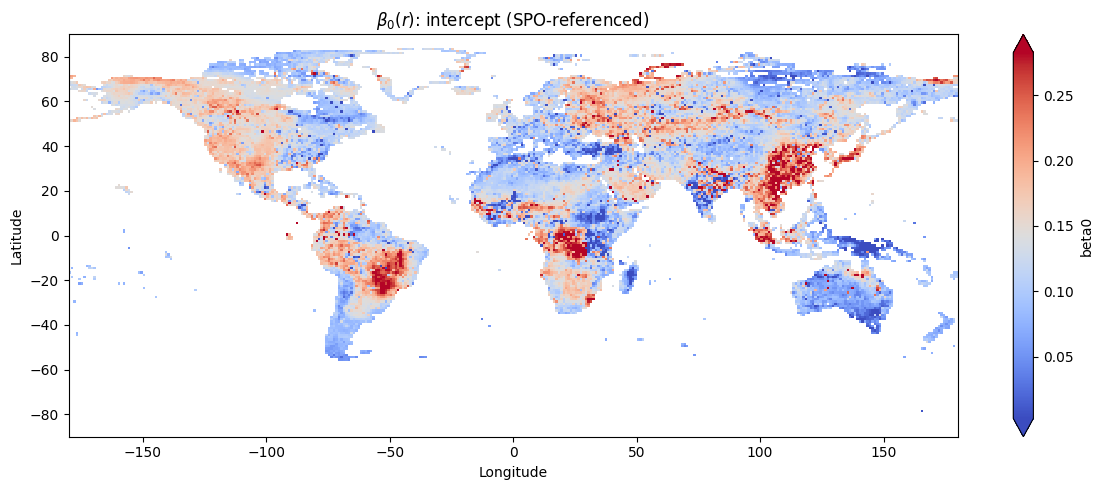

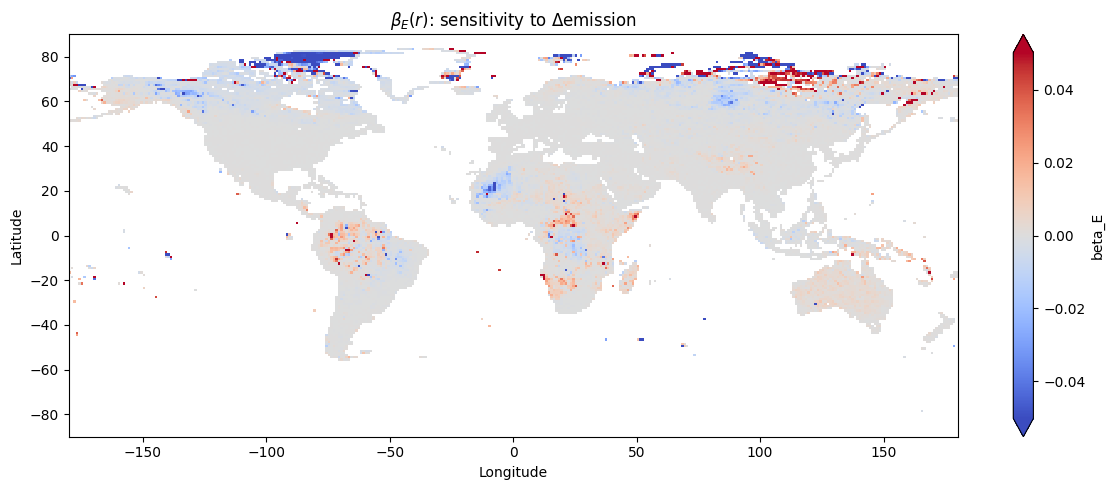

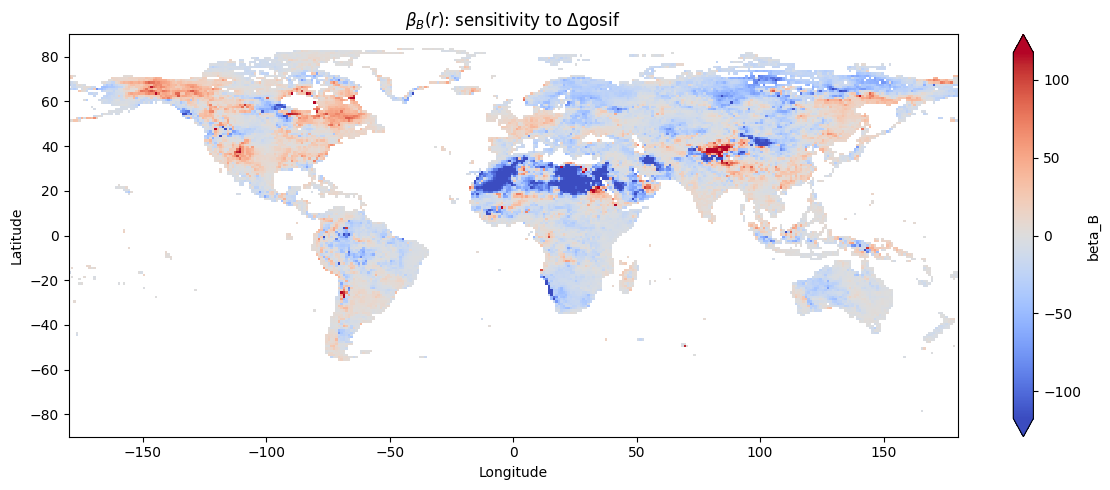

In [16]:
plot_map(out["beta0"],  title=r"$\beta_0(r)$: intercept (SPO-referenced)", save_path=FIGURE_DIR/"beta0_spo_delta.png")
plot_map(out["beta_E"], title=r"$\beta_E(r)$: sensitivity to $\Delta$emission", save_path=FIGURE_DIR/"betaE_spo_delta.png")
plot_map(out["beta_B"], title=r"$\beta_B(r)$: sensitivity to $\Delta$gosif", save_path=FIGURE_DIR/"betaB_spo_delta.png")

## 10. Model-quality maps: $R^2$ and RMSE

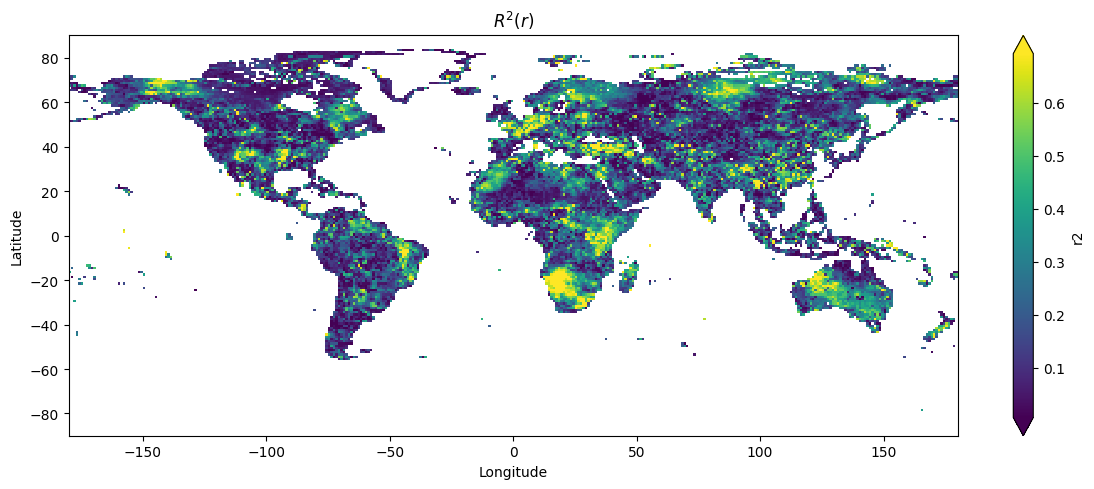

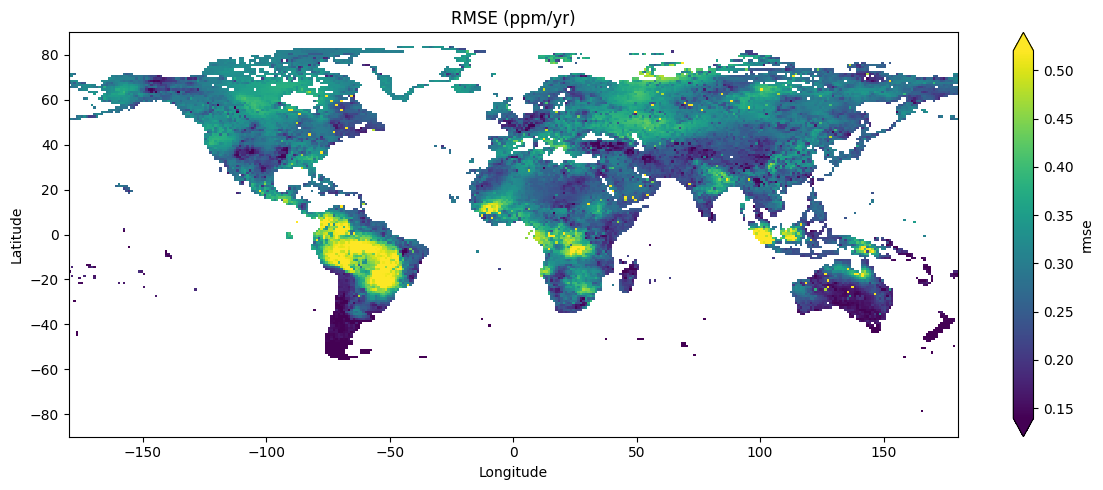

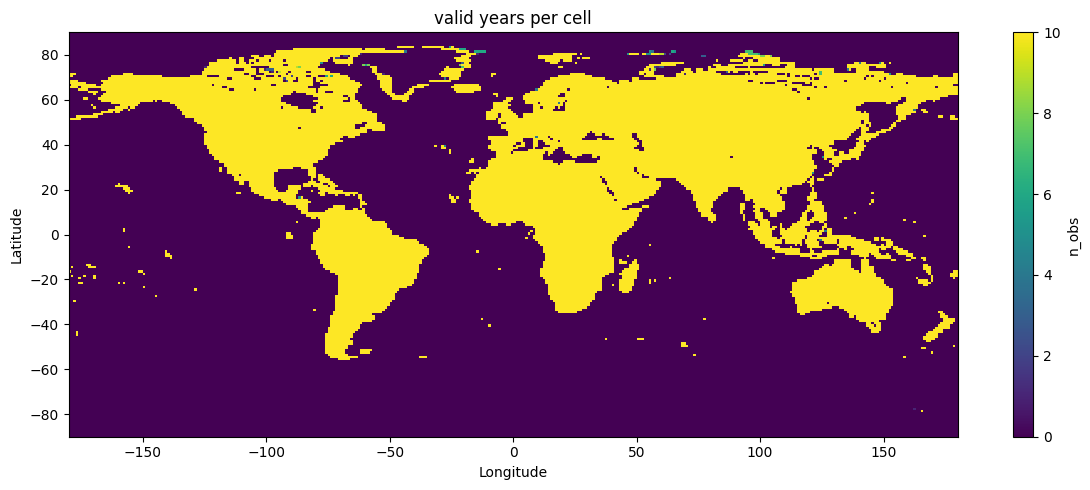

In [18]:
plot_map(out["r2"],   title=r"$R^2(r)$", cmap="viridis", save_path=FIGURE_DIR/"r2_spo_delta.png")
plot_map(out["rmse"], title="RMSE (ppm/yr)", cmap="viridis", save_path=FIGURE_DIR/"rmse_spo_delta.png")
plot_map(out["n_obs"], title="valid years per cell", cmap="viridis", robust=False, save_path=FIGURE_DIR/"nobs_spo_delta.png")

## 11. Global summary

In [19]:
rows = {}
for v in ["beta0", "beta_E", "beta_B", "r2", "rmse"]:
    a = out[v].values
    rows[v] = {"n_finite": int(np.isfinite(a).sum()),
               "mean": np.nanmean(a), "median": np.nanmedian(a),
               "q05": np.nanquantile(a, .05), "q95": np.nanquantile(a, .95)}
pd.DataFrame(rows).T

,n_finite,mean,median,q05,q95
beta0,17547.0,0.132406,0.129382,0.038375,0.240234
beta_E,17547.0,-9.766511,0.000002,-0.009562,0.008606
beta_B,17547.0,-8.592171,-4.567863,-62.452183,36.618708
r2,17547.0,0.222127,0.171370,0.015542,0.597308
rmse,17547.0,0.293194,0.287364,0.164690,0.439075


## 12. Inspect one cell in 3D: points + fitted plane

Axes are $\Delta E$, $\Delta B$, and the SPO-referenced growth-rate anomaly. The orange
surface is the local plane $\beta_0+\beta_E\,\Delta E+\beta_B\,\Delta B$.

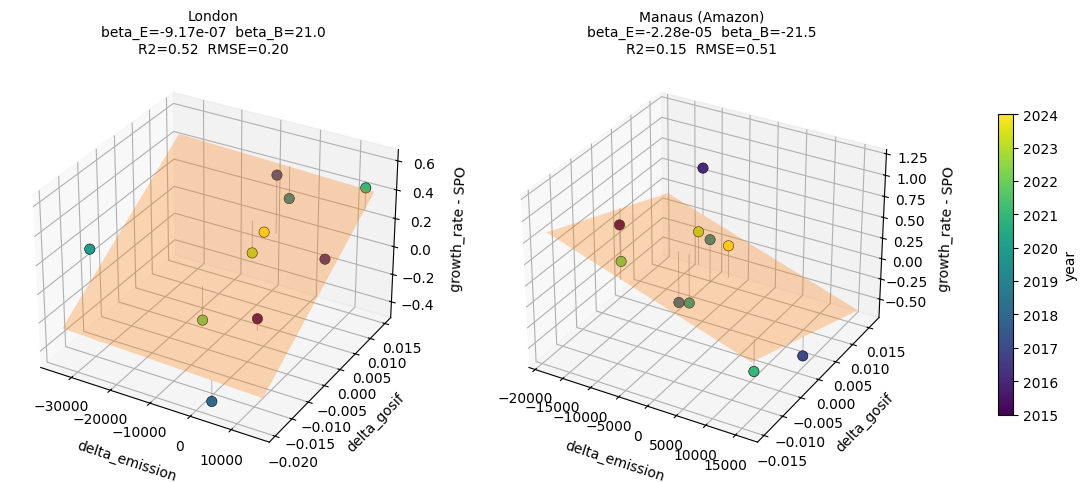

In [20]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

SITES = {"London": (51.5074, -0.1278), "Manaus (Amazon)": (-3.119, -60.022)}

fig = plt.figure(figsize=(15, 6.5))
for i, (name, (la, lo)) in enumerate(SITES.items(), 1):
    cell = ds.sel(lat=la, lon=lo, method="nearest")
    c    = out.sel(lat=la, lon=lo, method="nearest")
    spo_v = gr.sel(lat=slice(-90, SPO_LAT_MAX)).mean(["lat", "lon"]).values

    E = cell[EMISSION_VAR].values.astype(float)
    B = cell[BIO_VAR].values.astype(float)
    z = cell[TARGET_VAR].values.astype(float) - spo_v
    b0, bE, bB = float(c.beta0), float(c.beta_E), float(c.beta_B)
    r2v, rmsev = float(c.r2), float(c.rmse)

    ax = fig.add_subplot(1, 2, i, projection="3d")
    Eg = np.linspace(np.nanmin(E), np.nanmax(E), 12)
    Bg = np.linspace(np.nanmin(B), np.nanmax(B), 12)
    EE, BB = np.meshgrid(Eg, Bg)
    ax.plot_surface(EE, BB, b0 + bE*EE + bB*BB, alpha=0.3, color="tab:orange", shade=False)
    sc = ax.scatter(E, B, z, c=ds["time"].values, cmap="viridis", s=55,
                    edgecolor="k", linewidth=0.4, depthshade=False)
    for ei, bi, zi in zip(E, B, z):
        ax.plot([ei, ei], [bi, bi], [zi, b0+bE*ei+bB*bi], color="gray", lw=0.6, alpha=0.6)
    ax.set_xlabel("\n" + EMISSION_VAR); ax.set_ylabel("\n" + BIO_VAR)
    ax.set_zlabel("\ngrowth_rate - SPO")
    ax.set_title(f"{name}\nbeta_E={bE:.2e}  beta_B={bB:.1f}\nR2={r2v:.2f}  RMSE={rmsev:.2f}", fontsize=10)
fig.colorbar(sc, ax=fig.axes, shrink=0.6, pad=0.08, label="year")
plt.show()

## 13. Interpretation notes

- The target is now **local growth rate minus the South Pole background**, so $\beta_0$ is the
  mean local enhancement when the drivers don't change year-to-year.
- Predictors are **year-to-year changes** ($\Delta E$, $\Delta B$) in raw units. $\beta_E$ is the
  ppm/yr response of the local growth-rate anomaly to a one-unit change in annual emissions;
  $\beta_B$ likewise for SIF.
- The differenced design removes slow trends and common offsets, which usually **lowers $R^2$**
  (you are explaining year-to-year wiggles, the hardest part) but gives a cleaner read on
  *responses to change*. Compare the RMSE map to judge where predictions are tight.
- Coefficients remain **statistical associations**, not causal flux sensitivities: atmospheric
  CO$_2$ is transported and mixed, and with ~10 years the per-cell maps are exploratory
  fingerprints. Coarse-graining over regions/borders averages the per-cell noise down.